In [ ]:
%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import polars as pl

# x = requests.get('https://api.opendota.com/api/publicMatches', params={'less_than_match_id':7075980402})

In [4]:
# from tqdm import tqdm

# df = pl.read_parquet('../DATA/tmp_03.20.2023.10.08.35.parquet').to_pandas()
# SET = set()
# for idx, row in tqdm(df.iterrows()):
#     SET.update(row['winner_team'])

# TRANSFORM = {hero_id : idx + 1 for idx, hero_id in enumerate(list(SET))}
# TRANSFORM

In [4]:
df = pl.read_parquet("DATA/tmp_15_nov_25.parquet")
df = df.with_columns(
    pl.col("avg_rank_tier")
    .map_elements(lambda x: min(5, x // 10 - 1), return_dtype=pl.Int64)
    .alias("avg_rank_tier"),
    pl.when("radiant_win")
    .then("radiant_team")
    .otherwise("dire_team")
    .alias("winner_team"),
    pl.when("radiant_win")
    .then("dire_team")
    .otherwise("radiant_team")
    .alias("loser_team"),
).drop(["dire_team", "radiant_team", "radiant_win"])
DICTS = df.to_dicts()

In [5]:
df

match_id,match_seq_num,duration,start_time,game_mode,avg_rank_tier,winner_team,loser_team
i64,i64,i64,i64,i64,i64,list[i64],list[i64]
8516695910,7153484301,2816,1760782739,22,2,"[94, 112, … 2]","[70, 91, … 21]"
8516695613,7153477697,2463,1760782739,22,3,"[14, 72, … 27]","[8, 83, … 138]"
8516695614,7153471005,2101,1760782739,22,5,"[86, 120, … 84]","[21, 52, … 33]"
8516695606,7153467124,1864,1760782739,22,1,"[70, 8, … 30]","[129, 53, … 11]"
8516695616,7153461225,1552,1760782739,22,5,"[64, 36, … 100]","[75, 135, … 111]"
…,…,…,…,…,…,…,…
8559599113,7189199131,1117,1763200943,22,2,"[106, 101, … 48]","[128, 86, … 79]"
8559599214,7189196571,999,1763200948,4,1,"[70, 31, … 66]","[76, 8, … 17]"
8559600216,7189199567,1098,1763200993,22,4,"[9, 48, … 59]","[39, 128, … 5]"


In [6]:
df["game_mode"].value_counts()

game_mode,count
i64,u32
2,7235
3,22373
22,2646356
12,2
16,110
5,8
1,34
4,102125


In [7]:
TEST_DICTS = DICTS[-len(DICTS) // 20 :]
TRAIN_DICTS = DICTS[: -len(DICTS) // 20]
len(TRAIN_DICTS), len(TEST_DICTS)

(2639330, 138913)

In [8]:
from picker.model.dataset import TeamDataset

In [9]:
# from tqdm import tqdm

# df = pl.read_parquet('../DATA/tmp_03.20.2023.10.08.35.parquet').to_pandas()
# SET = set()
# for idx, row in tqdm(df.iterrows()):
#     SET.update(row['winner_team'])

# TRANSFORM = {hero_id : idx + 1 for idx, hero_id in enumerate(list(SET))}
# TRANSFORM

In [10]:
train_data = TeamDataset("", dicts_override=TRAIN_DICTS, p=0.2)
test_data1 = TeamDataset("", dicts_override=TEST_DICTS, p=0.0)
test_data2 = TeamDataset("", dicts_override=TEST_DICTS, p=0.2)

In [11]:
from picker.model.training_model import run_training
from picker.model.transformer import TransformerModel
from picker.model.constants import HERO_TRANSFORM

In [12]:
# embedding_dict = {'team': [len(HERO_TRANSFORM) + 1, 15], 'enemy': [len(HERO_TRANSFORM) + 1, 32]}
embedding_dict = {"team": [len(HERO_TRANSFORM) + 1, 32 - 3 - 1], "rank": [6, 3]}
model = TransformerModel(
    embedding_dict=embedding_dict,
    num_heads=8,
    num_layers=6,
)

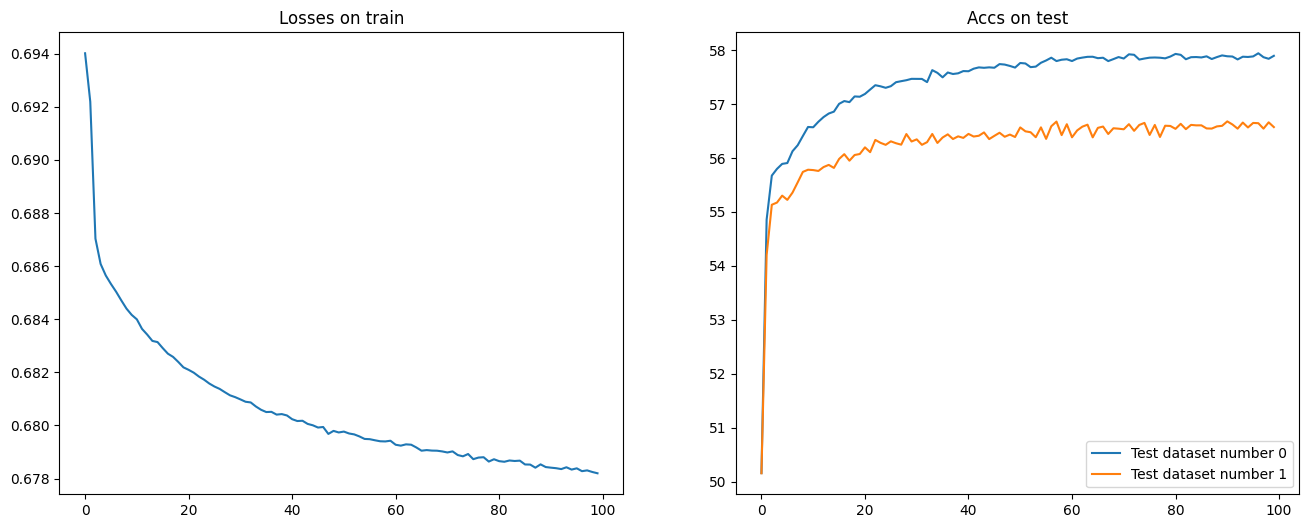

saved model to `trans-32-0.2-v2.pth`


In [13]:
from torch.nn import CrossEntropyLoss
import torch

run_training(
    model=model,
    name="trans-32-0.2-v2",
    train_data=train_data,
    test_datas=[test_data1, test_data2],
    optimizer=torch.optim.Adam(model.parameters(), lr=3e-4),
    criterion=CrossEntropyLoss(),
    epochs=100,
    batch_size=1024 * 8,
    device="cuda",
)

In [14]:
torch.save(model.state_dict(), "zhopa2.pth")

In [15]:
%debug

> /home/qc7/.cache/pypoetry/virtualenvs/picker-aqmUO_25-py3.10/lib/python3.10/site-packages/torch/_utils.py(543)reraise()
    541             # instantiate since we don't know how to
    542             raise RuntimeError(msg) from None
--> 543         raise exception
    544 
    545 



ipdb>  u


> /home/qc7/.cache/pypoetry/virtualenvs/picker-aqmUO_25-py3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py(1359)_process_data()
   1357         self._try_put_index()
   1358         if isinstance(data, ExceptionWrapper):
-> 1359             data.reraise()
   1360         return data
   1361 



ipdb>  u


> /home/qc7/.cache/pypoetry/virtualenvs/picker-aqmUO_25-py3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py(1333)_next_data()
   1331             else:
   1332                 del self._task_info[idx]
-> 1333                 return self._process_data(data)
   1334 
   1335     def _try_put_index(self):



...

ipdb>  d


> /home/qc7/.cache/pypoetry/virtualenvs/picker-aqmUO_25-py3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py(1333)_next_data()
   1331             else:
   1332                 del self._task_info[idx]
-> 1333                 return self._process_data(data)
   1334 
   1335     def _try_put_index(self):



ipdb>  d


> /home/qc7/.cache/pypoetry/virtualenvs/picker-aqmUO_25-py3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py(1359)_process_data()
   1357         self._try_put_index()
   1358         if isinstance(data, ExceptionWrapper):
-> 1359             data.reraise()
   1360         return data
   1361 



ipdb>  exit


In [15]:
import torch
from picker.model.transformer import TransformerModel
from picker.model.constants import HERO_TRANSFORM

embedding_dict = {"team": [len(HERO_TRANSFORM) + 1, 32 - 3 - 1], "rank": [6, 3]}
model = TransformerModel(
    embedding_dict=embedding_dict,
    num_heads=8,
    num_layers=6,
)
model.load_state_dict(torch.load("zhopa2.pth"))

model.to("cpu")
model.eval()
pass

In [16]:
# script = torch.jit.script(model)
torch.save(model, "zhopa2.raw_model")

In [17]:
%%time

for HERO in HERO_TRANSFORM.values():
    print(
        torch.softmax(
            model(
                (
                    torch.as_tensor([[0, 0, 0, 0, HERO] + [0, 0, 0, 0, 0]]),
                    torch.as_tensor(5),
                )  # ancient + rapier + immortal rank
            ),
            dim=-1,
        ),
        "\n",
        torch.softmax(
            model(
                (
                    torch.as_tensor([[HERO, 0, 0, 0, 0] + [0, 0, 0, 0, 0]]),
                    torch.as_tensor(5),
                )  # ancient + rapier + immortal rank
            ),
            dim=-1,
        ),
        "\n",
        torch.softmax(
            model(
                (
                    torch.as_tensor([[0, 0, 0, 0, 0] + [HERO, 0, 0, 0, 0]]),
                    torch.as_tensor(5),
                )  # ancient + rapier + immortal rank
            ),
            dim=-1,
        ),
    )
    print("-" * 60)

tensor([[0.5032, 0.4968]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.5032, 0.4968]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.5032, 0.4968]], grad_fn=<SoftmaxBackward0>)
------------------------------------------------------------
tensor([[0.4953, 0.5047]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.4953, 0.5047]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.5017, 0.4983]], grad_fn=<SoftmaxBackward0>)
------------------------------------------------------------
tensor([[0.4949, 0.5051]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.4949, 0.5051]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.5129, 0.4871]], grad_fn=<SoftmaxBackward0>)
------------------------------------------------------------
tensor([[0.4977, 0.5023]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.4977, 0.5023]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.5119, 0.4881]], grad_fn=<SoftmaxBackward0>)
------------------------------------------------------------
tensor([[0.5068, 0.4932]], grad_fn=<SoftmaxBackward0>) 
 tensor([[0.5068, 0.4932

In [36]:
len(HERO_TRANSFORM)

127

In [ ]:
%debug

> /home/yarik/shad/picker/picker/model/training_model.py(57)plot_stuff()
     55     if len(accs):
     56         for idx in range(accs_np.shape[1]):
---> 57             ax2.plot(accs[:, idx], label = f'Test dataset number {idx}')
     58 
     59     ax2.set_title("Accs on test")

ipdb> idx
0
ipdb> accs[:, idx]
*** TypeError: list indices must be integers or slices, not tuple


In [32]:
import torch

A = torch.cat((torch.ones(512, 5, 1), torch.zeros(512, 5, 1)), dim=-2)

In [35]:
torch.cat((torch.rand(512, 10, 63), A), dim=-1).shape

torch.Size([512, 10, 64])

In [60]:
emb = torch.cat(embs).reshape(1, 10, -1)
res = model(emb, None)

In [61]:
res

tensor([[0.4648]], grad_fn=<AddmmBackward0>)

In [56]:
a = torch.rand(1, 10, 64)
b = torch.rand(1, 1, 64)

In [57]:
torch.cat((a, b), dim=1)

tensor([[[0.0823, 0.2277, 0.4079, 0.9386, 0.0742, 0.7202, 0.3607, 0.9005,
          0.1608, 0.2063, 0.7980, 0.9442, 0.0333, 0.5649, 0.2936, 0.4545,
          0.4625, 0.3905, 0.5795, 0.6908, 0.0839, 0.7522, 0.9392, 0.1067,
          0.3177, 0.5344, 0.1385, 0.7366, 0.2210, 0.7947, 0.2109, 0.0716,
          0.8087, 0.5818, 0.2675, 0.9628, 0.7965, 0.6796, 0.1220, 0.6453,
          0.2468, 0.2309, 0.3061, 0.2880, 0.1987, 0.7911, 0.5555, 0.4565,
          0.8999, 0.4815, 0.6246, 0.6285, 0.7902, 0.0816, 0.5806, 0.1977,
          0.6592, 0.5274, 0.3737, 0.8188, 0.5043, 0.8749, 0.7966, 0.2408],
         [0.9915, 0.3214, 0.3582, 0.4512, 0.1294, 0.6715, 0.8483, 0.3055,
          0.6333, 0.0336, 0.1905, 0.7927, 0.0481, 0.4222, 0.6530, 0.4618,
          0.4607, 0.9218, 0.1592, 0.9127, 0.1080, 0.6349, 0.9745, 0.8846,
          0.1505, 0.5538, 0.9617, 0.9514, 0.5724, 0.8122, 0.7971, 0.8665,
          0.4984, 0.1422, 0.6348, 0.0502, 0.9907, 0.4200, 0.7669, 0.3436,
          0.3604, 0.8022, 0.5990, 0.7